In [1]:
!pip install biopython

from Bio import Entrez, SeqIO
from Bio import Phylo
import numpy as np
import matplotlib.pyplot as plt
import io
import copy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.1 MB/s eta 0:00:00


In [2]:
Entrez.email = "jperezvi@unsa.edu.pe"

accessions = [
    "NC_012920.1", "NC_001643.1", "NC_001645.1",
    "NC_005089.1", "NC_002008.4", "NC_002333.2", "NC_006839.1"
]

species = [
    "Homo_sapiens", "Pan_troglodytes", "Gorilla_gorilla",
    "Mus_musculus", "Canis_lupus", "Danio_rerio", "Xenopus_tropicalis"
]

sequences = {}

for acc, name in zip(accessions, species):
    handle = Entrez.efetch(db="nucleotide", id=acc, rettype="gb", retmode="text")
    record = SeqIO.read(handle, "genbank")
    handle.close()

    for feature in record.features:
        if feature.type == "CDS":
            gene_name = feature.qualifiers.get("gene", [""])[0]
            if "COX1" in gene_name or "COI" in gene_name:
                sequences[name] = str(feature.extract(record.seq))
                break

In [7]:
def p_distance(seq1, seq2):
    min_len = min(len(seq1), len(seq2))
    diff = sum(1 for a, b in zip(seq1[:min_len], seq2[:min_len]) if a != b)
    return diff / min_len

n_species = len(species)
dist_matrix = np.zeros((n_species, n_species))

for i in range(n_species):
    for j in range(n_species):
        if i != j:
            dist_matrix[i][j] = p_distance(sequences[species[i]], sequences[species[j]])

print("Matriz de Distancias Inicial:")
print(np.round(dist_matrix, 4))

Matriz de Distancias Inicial:
[[0.     0.0869 0.1089 0.2224 0.2296 0.2581 0.2451]
 [0.0869 0.     0.1005 0.2289 0.2315 0.2652 0.2503]
 [0.1089 0.1005 0.     0.2298 0.2278 0.2592 0.2386]
 [0.2224 0.2289 0.2298 0.     0.1987 0.2084 0.2233]
 [0.2296 0.2315 0.2278 0.1987 0.     0.2324 0.2324]
 [0.2581 0.2652 0.2592 0.2084 0.2324 0.     0.2179]
 [0.2451 0.2503 0.2386 0.2233 0.2324 0.2179 0.    ]]


In [8]:
nodes = species.copy()
distances = dist_matrix.tolist()

while len(nodes) > 2:
    n_curr = len(nodes)
    q_matrix = np.zeros((n_curr, n_curr))
    r = [sum(distances[i]) for i in range(n_curr)]

    for i in range(n_curr):
        for j in range(n_curr):
            if i != j:
                q_matrix[i][j] = (n_curr - 2) * distances[i][j] - r[i] - r[j]

    print(f"\nMatriz Q (Iteración con {n_curr} nodos):")
    print(np.round(q_matrix, 4))

    min_val = float('inf')
    min_i, min_j = -1, -1
    for i in range(n_curr):
        for j in range(i + 1, n_curr):
            if q_matrix[i][j] < min_val:
                min_val = q_matrix[i][j]
                min_i, min_j = i, j

    li = (distances[min_i][min_j] / 2) + ((r[min_i] - r[min_j]) / (2 * (n_curr - 2)))
    lj = distances[min_i][min_j] - li

    u_name = f"({nodes[min_i]}:{li:.4f},{nodes[min_j]}:{lj:.4f})"

    new_distances = []
    for k in range(n_curr):
        if k != min_i and k != min_j:
            d_uk = (distances[min_i][k] + distances[min_j][k] - distances[min_i][min_j]) / 2
            new_distances.append(d_uk)

    nodes_left = [nodes[k] for k in range(n_curr) if k != min_i and k != min_j]
    dist_left = []

    for i in range(n_curr):
        if i != min_i and i != min_j:
            row = []
            for j in range(n_curr):
                if j != min_i and j != min_j:
                    row.append(distances[i][j])
            dist_left.append(row)

    for i in range(len(nodes_left)):
        dist_left[i].append(new_distances[i])

    new_row = new_distances + [0.0]
    dist_left.append(new_row)

    nodes = nodes_left + [u_name]
    distances = dist_left

final_len = distances[0][1] / 2
final_tree = f"({nodes[0]}:{final_len:.4f},{nodes[1]}:{final_len:.4f});"

print("\nEstructura final del árbol (Formato Newick):")
print(final_tree)


Matriz Q (Iteración con 7 nodos):
[[ 0.     -1.88   -1.7712 -1.3505 -1.3556 -1.3018 -1.333 ]
 [-1.88    0.     -1.8256 -1.3304 -1.3582 -1.2785 -1.3194]
 [-1.7712 -1.8256  0.     -1.3275 -1.378  -1.3101 -1.3796]
 [-1.3505 -1.3304 -1.3275  0.     -1.6704 -1.7107 -1.6027]
 [-1.3556 -1.3582 -1.378  -1.6704  0.     -1.6318 -1.5981]
 [-1.3018 -1.2785 -1.3101 -1.7107 -1.6318  0.     -1.7592]
 [-1.333  -1.3194 -1.3796 -1.6027 -1.5981 -1.7592  0.    ]]

Matriz Q (Iteración con 6 nodos):
[[ 0.     -1.14   -1.1837 -1.116  -1.1788 -1.6246]
 [-1.14    0.     -1.326  -1.3449 -1.2656 -1.1666]
 [-1.1837 -1.326   0.     -1.285  -1.2653 -1.1831]
 [-1.116  -1.3449 -1.285   0.     -1.3808 -1.1163]
 [-1.1788 -1.2656 -1.2653 -1.3808  0.     -1.1524]
 [-1.6246 -1.1666 -1.1831 -1.1163 -1.1524  0.    ]]

Matriz Q (Iteración con 5 nodos):
[[ 0.     -1.0499 -1.0473 -1.0002 -1.0307]
 [-1.0499  0.     -1.0099 -1.0075 -1.0608]
 [-1.0473 -1.0099  0.     -1.0774 -0.9936]
 [-1.0002 -1.0075 -1.0774  0.     -1.0431]
 [

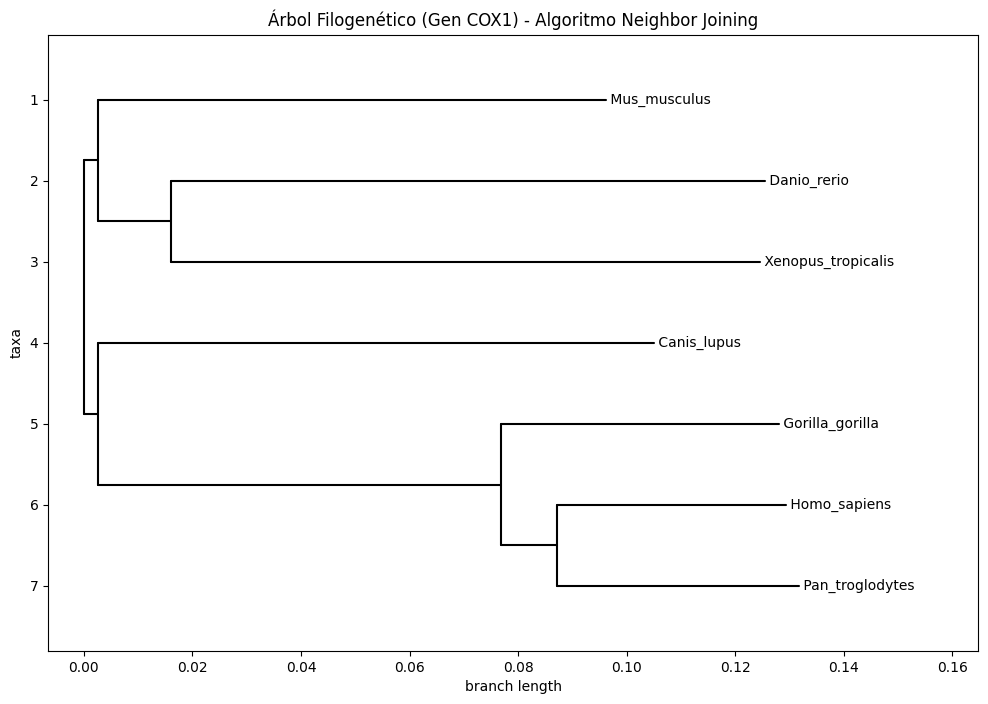

In [9]:
tree = Phylo.read(io.StringIO(final_tree), "newick")

fig = plt.figure(figsize=(12, 8))
axes = fig.add_subplot(1, 1, 1)

Phylo.draw(tree, axes=axes, do_show=False)

plt.title("Árbol Filogenético (Gen COX1) - Algoritmo Neighbor Joining")
plt.show()